 implementation of nonlinear feature extraction method using deep neural networks using `JAX` autograd.

Q2 data shapes: (20000, 784) (20000, 10) (5000, 784) (5000, 10)

Training config: {'sizes': [784, 256, 32, 128, 10], 'epochs': 15, 'lr': 0.01}
epoch 01 | loss=2.3046 | val_acc=0.1140
epoch 02 | loss=2.3043 | val_acc=0.1140
epoch 03 | loss=2.3041 | val_acc=0.1140
epoch 04 | loss=2.3039 | val_acc=0.1140
epoch 05 | loss=2.3038 | val_acc=0.1140
epoch 06 | loss=2.3036 | val_acc=0.1140
epoch 07 | loss=2.3035 | val_acc=0.1140
epoch 08 | loss=2.3034 | val_acc=0.1140
epoch 09 | loss=2.3033 | val_acc=0.1140
epoch 10 | loss=2.3032 | val_acc=0.1140
epoch 11 | loss=2.3032 | val_acc=0.1140
epoch 12 | loss=2.3031 | val_acc=0.1140
epoch 13 | loss=2.3030 | val_acc=0.1140
epoch 14 | loss=2.3030 | val_acc=0.1140
epoch 15 | loss=2.3030 | val_acc=0.1140

Training config: {'sizes': [784, 512, 64, 256, 10], 'epochs': 15, 'lr': 0.01}
epoch 01 | loss=2.3070 | val_acc=0.1140
epoch 02 | loss=2.3067 | val_acc=0.1140
epoch 03 | loss=2.3065 | val_acc=0.1140
epoch 04 | loss=2.3063 | val_acc=0.1140
epoch 05 | loss=2.

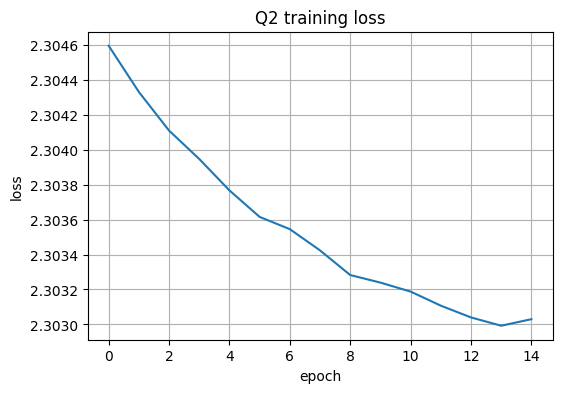

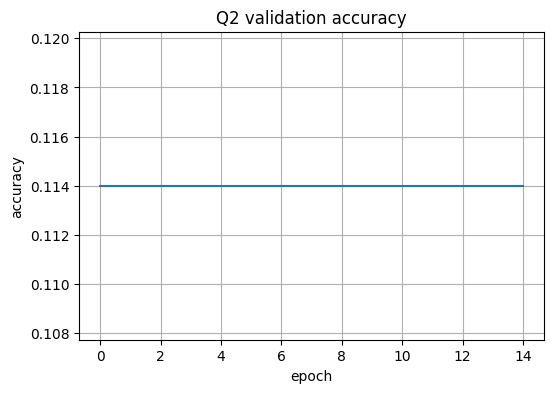

Bottleneck feature shapes: (60000, 32) (10000, 32)
C=0.1, gamma=scale, acc=0.9838
C=0.1, gamma=0.01, acc=0.9810
C=0.1, gamma=0.1, acc=0.9746
C=1, gamma=scale, acc=0.9894
C=1, gamma=0.01, acc=0.9861
C=1, gamma=0.1, acc=0.9871
C=10, gamma=scale, acc=0.9889
C=10, gamma=0.01, acc=0.9884
C=10, gamma=0.1, acc=0.9871

Best bottleneck + RBF SVM config: {'C': 1, 'gamma': 'scale'}
Final test accuracy on 1 vs 7: 0.9893666204345816


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import jax
import jax.numpy as jnp
from jax import grad, jit, value_and_grad
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml
import itertools


# Load MNIST Dataset and Preprocess Data
# - Fetches MNIST, normalizes pixel values, and converts labels to one-hot encoding.
# - Provides an option to use a smaller subset for faster experimentation.
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X_all = mnist.data.astype(np.float32) / 255.0
y_all = mnist.target.astype(int)

X_train_all = X_all[:60000]
y_train_all = y_all[:60000]
X_test_all  = X_all[60000:]
y_test_all  = y_all[60000:]

num_classes = 10

def one_hot(y, k=10):
    """Converts integer labels to one-hot encoded vectors."""
    out = np.zeros((len(y), k), dtype=np.float32)
    out[np.arange(len(y)), y] = 1.0
    return out

Y_train_oh = one_hot(y_train_all, 10)
Y_test_oh = one_hot(y_test_all, 10)

# Small subset option for faster experiments
# Change USE_SUBSET = False to use full training set
USE_SUBSET = True

if USE_SUBSET:
    n_train = 20000
    n_test = 5000
    X_train = X_train_all[:n_train]
    y_train = y_train_all[:n_train]
    Y_train = Y_train_oh[:n_train]

    X_test = X_test_all[:n_test]
    y_test = y_test_all[:n_test]
    Y_test = Y_test_oh[:n_test]
else:
    X_train = X_train_all
    y_train = y_train_all
    Y_train = Y_train_oh

    X_test = X_test_all
    y_test = y_test_all
    Y_test = Y_test_oh

print("Q2 data shapes:", X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)


# JAX-based Multi-Layer Perceptron (MLP) Implementation with Bottleneck
# - Defines functions for initializing network parameters, forward pass, loss, and updates.
# - The 'bottleneck' feature is extracted from a specific hidden layer.
def init_layer_params(m, n, key):
    """Initializes weights and biases for a single layer."""
    w_key, _ = jax.random.split(key)
    W = 0.01 * jax.random.normal(w_key, (m, n))
    b = jnp.zeros((n,))
    return W, b

def init_network(sizes, seed=0):
    """Initializes all parameters for the MLP network based on layer sizes."""
    keys = jax.random.split(jax.random.PRNGKey(seed), len(sizes) - 1)
    params = [init_layer_params(sizes[i], sizes[i+1], keys[i]) for i in range(len(sizes)-1)]
    return params

def relu(x):
    """Rectified Linear Unit (ReLU) activation function."""
    return jnp.maximum(0, x)

def softmax_cross_entropy(logits, y_true):
    """Calculates softmax cross-entropy loss."""
    logits = logits - jnp.max(logits, axis=1, keepdims=True)
    log_probs = logits - jnp.log(jnp.sum(jnp.exp(logits), axis=1, keepdims=True) + 1e-9)
    return -jnp.mean(jnp.sum(y_true * log_probs, axis=1))

def forward(params, X):
    """Performs a forward pass through the network and extracts bottleneck features."""
    activations = X
    bottleneck_features = None

    for i, (W, b) in enumerate(params):
        z = activations @ W + b
        if i < len(params) - 1:
            activations = relu(z)
            # save the middle hidden layer as bottleneck feature
            if i == 1: # Assuming the bottleneck is the second hidden layer
                bottleneck_features = activations
        else:
            activations = z # Output layer, no activation yet

    return activations, bottleneck_features

def loss_fn(params, X, y_true, l2=1e-4):
    """Computes the total loss, including softmax cross-entropy and L2 regularization."""
    logits, _ = forward(params, X)
    ce = softmax_cross_entropy(logits, y_true)
    reg = sum(jnp.sum(W**2) for W, b in params) # L2 regularization on weights
    return ce + l2 * reg

@jit
def update(params, Xb, yb, lr, l2):
    """Performs one step of gradient descent using JAX's autograd."""
    loss, grads = value_and_grad(loss_fn)(params, Xb, yb, l2)
    new_params = []
    for (W, b), (gW, gb) in zip(params, grads):
        new_params.append((W - lr * gW, b - lr * gb))
    return new_params, loss

def predict_class(params, X):
    """Predicts class labels for given input features."""
    logits, _ = forward(params, X)
    return np.array(jnp.argmax(logits, axis=1))

def extract_bottleneck(params, X):
    """Extracts the bottleneck features from the trained network."""
    _, feat = forward(params, X)
    return np.array(feat)

def train_mlp_bottleneck(X_train, Y_train, X_val, Y_val, sizes, epochs=20, batch_size=256, lr=0.01, l2=1e-4, seed=0):
    """Trains the MLP bottleneck model and tracks training history."""
    params = init_network(sizes, seed=seed)
    n = X_train.shape[0]
    history = {"train_loss": [], "val_acc": []}

    for epoch in range(epochs):
        perm = np.random.permutation(n)
        Xs = X_train[perm]
        Ys = Y_train[perm]

        losses = []
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            Xb = jnp.array(Xs[start:end])
            yb = jnp.array(Ys[start:end])
            params, loss = update(params, Xb, yb, lr, l2)
            losses.append(float(loss))

        val_pred = predict_class(params, jnp.array(X_val))
        val_acc = accuracy_score(np.argmax(Y_val, axis=1), val_pred)

        history["train_loss"].append(np.mean(losses))
        history["val_acc"].append(val_acc)
        print(f"epoch {epoch+1:02d} | loss={np.mean(losses):.4f} | val_acc={val_acc:.4f}")

    return params, history


# DNN Model Selection and Training
# - Splits training data into training and validation sets.
# - Defines multiple network configurations (sizes, epochs, learning rates).
# - Trains each configuration and selects the one with the best validation accuracy.
X_tr, X_val, y_tr, y_val, Y_tr, Y_val = train_test_split(
    X_train, y_train, Y_train, test_size=0.1, random_state=42, stratify=y_train
)

configs = [
    {"sizes": [784, 256, 32, 128, 10], "epochs": 15, "lr": 0.01},
    {"sizes": [784, 512, 64, 256, 10], "epochs": 15, "lr": 0.01},
    {"sizes": [784, 256, 16, 128, 10], "epochs": 15, "lr": 0.01},
]

best_params = None
best_history = None
best_cfg = None
best_val_acc = -1

for cfg in configs:
    print("\nTraining config:", cfg)
    params, history = train_mlp_bottleneck(
        X_tr, Y_tr, X_val, Y_val,
        sizes=cfg["sizes"],
        epochs=cfg["epochs"],
        batch_size=256,
        lr=cfg["lr"],
        l2=1e-4,
        seed=42
    )
    peak_val = max(history["val_acc"])
    if peak_val > best_val_acc:
        best_val_acc = peak_val
        best_params = params
        best_history = history
        best_cfg = cfg

print("\nBest bottleneck config:", best_cfg)
print("Best validation accuracy:", best_val_acc)

# Plotting training loss and validation accuracy for the best model
plt.figure(figsize=(6,4))
plt.plot(best_history["train_loss"])
plt.title("Q2 training loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(best_history["val_acc"])
plt.title("Q2 validation accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.grid(True)
plt.show()


# Bottleneck Feature Extraction and SVM Classification
# - Extracts features using the best trained DNN.
# - Filters MNIST data to include only digits '1' and '7'.
# - Trains and evaluates an RBF SVM on these extracted features.
# - Performs hyperparameter tuning for the SVM.

# Extract bottleneck features from the full training and test datasets
train_feat = extract_bottleneck(best_params, jnp.array(X_train_all))
test_feat  = extract_bottleneck(best_params, jnp.array(X_test_all))

print("Bottleneck feature shapes:", train_feat.shape, test_feat.shape)

# Function to filter data for specific digits (e.g., '1' and '7')
def filter_digits(X, y, digits):
    mask = np.isin(y, digits)
    return X[mask], y[mask]

# Filter features and labels for '1' and '7' digits
Xtr17, ytr17 = filter_digits(train_feat, y_train_all, [1, 7])
Xte17, yte17 = filter_digits(test_feat, y_test_all, [1, 7])

# Convert '1' and '7' labels to binary for SVM (-1 and 1)
ytr17_bin = np.where(ytr17 == 1, -1, 1)
yte17_bin = np.where(yte17 == 1, -1, 1)

# Standardize the extracted features
scaler_feat = StandardScaler()
Xtr17 = scaler_feat.fit_transform(Xtr17)
Xte17 = scaler_feat.transform(Xte17)

best_svm = None
best_svm_acc = -1
best_svm_cfg = None

# Hyperparameter tuning for RBF SVM on bottleneck features
for C, gamma in itertools.product([0.1, 1, 10], ["scale", 0.01, 0.1]):
    clf = SVC(kernel="rbf", C=C, gamma=gamma)
    clf.fit(Xtr17, ytr17_bin)
    pred = clf.predict(Xte17)
    acc = accuracy_score(yte17_bin, pred)
    print(f"C={C}, gamma={gamma}, acc={acc:.4f}")

    if acc > best_svm_acc:
        best_svm_acc = acc
        best_svm = clf
        best_svm_cfg = {"C": C, "gamma": gamma}

print("\nBest bottleneck + RBF SVM config:", best_svm_cfg)
print("Final test accuracy on 1 vs 7:", best_svm_acc)


As we can see in these results, even though the model need a log time to run, the final test accuracy is pretty high. It is also noted that the more epochs done, the less training loss we would have, meaning in better results without changing the validation accuracy. It can be said that this is a good model of the SVM configuration with a C = 1. It could also be said that we can keep training the model for better results, but this could also may result in a overfitting and more computationally heavy code, that, without the necesarry resources, it is not even worth to do.